In [1]:
import PIAA_functions as PIAA
import numpy as np
import matplotlib.pyplot as plt

# Calculate the optimal coupling efficiency

## Parameters of the beams and of the fibers

In [2]:
En_diam = 10e-3
Ex_diam = 10e-3

# Data for the TAS fiber from Faber 2006
#wav_TAS = np.array([3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10])
wav_TAS = np.array([4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9])
wav_TAS *= 1e-6
mfd_TAS = np.array([22, 22.8, 24.6, 25.9, 27.9, 30.5, 33.5, 36.8, 40.6, 45.7, 51.8, 59.1, 68, 78.9, 91.9])
mfd_TAS = np.array([24.6, 25.9, 27.9, 30.5, 33.5, 36.8, 40.6, 45.7, 51.8, 59.1, 68])
mfd_TAS *= 1e-6
f_TAS = 46e-3

# Data for the AgBr fiber from Flatscher 2006
V_Flatscher = np.array([2.4, 2.2, 2, 1.8, 1.6, 1.4, 1.2, 1.1])
NA, r_core = 0.34, 10
wav_AgBr = 2*np.pi*r_core*NA/V_Flatscher
wav_AgBr *= 1e-6
mfd_AgBr = np.array([1.08, 1.133, 1.186, 1.292, 1.398, 1.61, 1.982, 2.248])*2*r_core
mfd_AgBr *= 1e-6
f_AgBr = 18e-3

fs_plot = 10

Entrance pupil =  0.9999936
Exit pupil =  0.9751103
Entrance PSF =  0.9700532
Exit PSF =  0.97325665


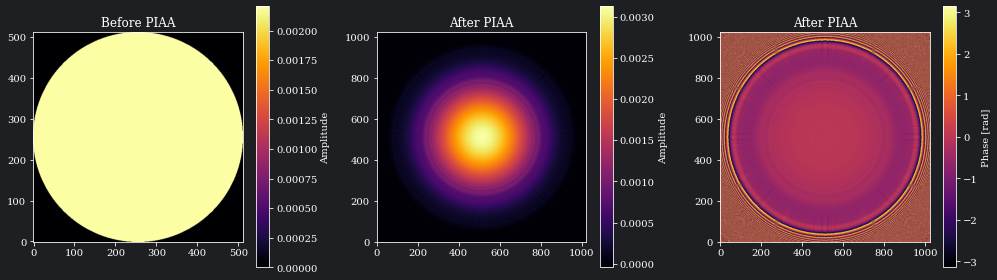

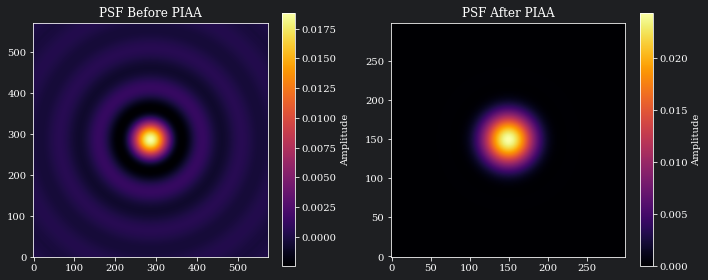

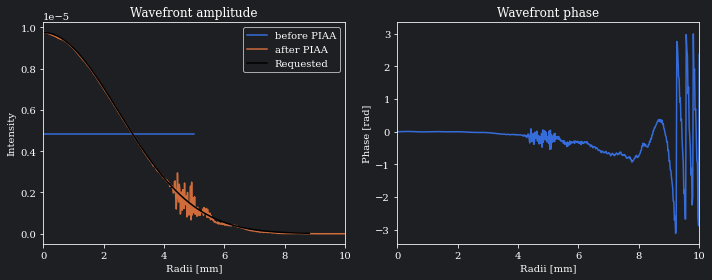

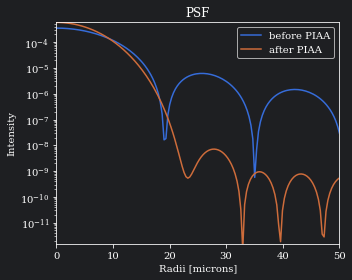

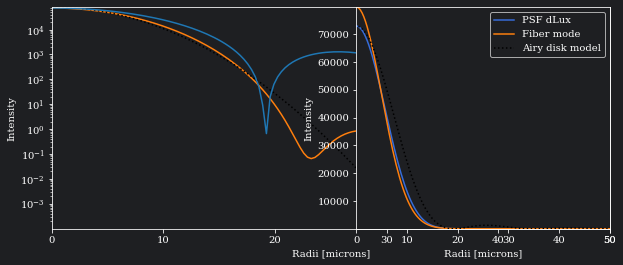

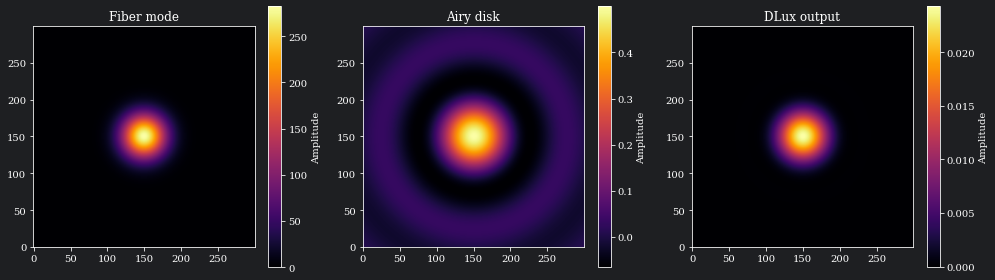

(Array(1., dtype=float32, weak_type=True), Array(0.8479413, dtype=float32), Array(0.99635804, dtype=float32))


'\nplt.figure(figsize = (1.5*3.2, 1.5*2.4))\nplt.plot(PIAA_test.r1*1000, PIAA_test.M1*1e6, label="M1", color="tab:blue")\nplt.plot(-PIAA_test.r1*1000, PIAA_test.M1*1e6, color="tab:blue")\nplt.plot(PIAA_test.r2*1000,-PIAA_test.M2*1e6, label="M2", color="tab:orange")\nplt.plot(-PIAA_test.r2*1000,-PIAA_test.M2*1e6, color="tab:orange")\nplt.xlabel("Radius [mm]", fontsize = fs_plot)\nplt.ylabel("Sag [microns]", fontsize = fs_plot)\n\nplt.title("PIAA mirrors for 10mm beam", fontsize = fs_plot)\nplt.legend()\nplt.savefig("images/PIAA_mirr.png", dpi = 300, bbox_inches = "tight")\nplt.show()\n'

In [3]:
PIAA_test = PIAA.PIAAforLIFE(
                            En_diam = En_diam,
                            Ex_diam = Ex_diam,
                            n = 500,
                            wave_mono = 4e-6,
                            mfd = 20e-6,
                            focal_length = 0,
                            apodized = True,
                            f_psf_size = 10,
                            )
""
PIAA_test.get_M1_M2()
PIAA_test.Mild_asphere_fit()
PIAA_test.do_PIAA()
PIAA_test.print_intensity()
PIAA_test.plot_im()
PIAA_test.plot_cross_sec()
PIAA_test.plot_fiber_modes()
print(PIAA_test.get_Ceff())

""
"""
plt.figure(figsize = (1.5*3.2, 1.5*2.4))
plt.plot(PIAA_test.r1*1000, PIAA_test.M1*1e6, label="M1", color="tab:blue")
plt.plot(-PIAA_test.r1*1000, PIAA_test.M1*1e6, color="tab:blue")
plt.plot(PIAA_test.r2*1000,-PIAA_test.M2*1e6, label="M2", color="tab:orange")
plt.plot(-PIAA_test.r2*1000,-PIAA_test.M2*1e6, color="tab:orange")
plt.xlabel("Radius [mm]", fontsize = fs_plot)
plt.ylabel("Sag [microns]", fontsize = fs_plot)

plt.title("PIAA mirrors for 10mm beam", fontsize = fs_plot)
plt.legend()
plt.savefig("images/PIAA_mirr.png", dpi = 300, bbox_inches = "tight")
plt.show()
"""

## Build the PIAA systems and get the ideal coupling efficiencies

In [4]:
PIAA_no_apod = PIAA.PIAAforLIFE(En_diam = En_diam,
                                Ex_diam = Ex_diam,
                                n = 500,
                                wave_mono = 4e-6,
                                mfd = 22e-6,
                                focal_length = f_TAS,
                                apodized = False,
                                )

PIAA_apod = PIAA.PIAAforLIFE(En_diam = En_diam,
                            Ex_diam = Ex_diam,
                            n = 500,
                            wave_mono = 4e-6,
                            mfd = 22e-6,
                            focal_length = f_TAS,
                            apodized = True,
                            )

# Calculation of the theoretical M1 and M2
PIAA_no_apod.get_M1_M2()
PIAA_apod.get_M1_M2()

# Fit of M1 and M2 with a mild asphere
PIAA_no_apod.Mild_asphere_fit()
PIAA_apod.Mild_asphere_fit()

# Recipients for the coupling efficiencies
Ceff_TAS_apod, Ceff_AgBr_apod = [], []
Ceff_TAS_noapod, Ceff_AgBr_noapod = [], []

# Define the focal length to optimize injection in the TAS fiber
PIAA_no_apod.focal_length = f_TAS
PIAA_apod.focal_length = f_TAS

# Define any errors in the alignment
pointing, shear = 0, 0 # Pointing in rad, shear in meters errors
PIAA_no_apod.pointing, PIAA_no_apod.shear = pointing, shear
PIAA_apod.pointing, PIAA_apod.shear = pointing, shear

In [5]:
# Calculate the coupling efficiencies for the different wavelengths and the different mode field diameter
for i in range(len(wav_TAS)):
    print("Doing wavelength ", "{:.2f}".format(wav_TAS[i]*1e6), " microns")
    """
    PIAA_no_apod.wave_mono = wav_TAS[i]
    PIAA_no_apod.mfd = mfd_TAS[i]
    PIAA_no_apod.do_PIAA()
    Ceff_TAS_noapod.append(PIAA_no_apod.get_Ceff())
    """
    
    PIAA_apod.wave_mono = wav_TAS[i]
    PIAA_apod.mfd = mfd_TAS[i]
    PIAA_apod.do_PIAA()
    Ceff_TAS_apod.append(PIAA_apod.get_Ceff())

# Define the focal length to optimize injection in the AgBr fiber
PIAA_no_apod.focal_length = f_AgBr
PIAA_apod.focal_length = f_AgBr

for i in range(len(wav_AgBr)):
    print("Doing wavelength ", "{:.2f}".format(wav_AgBr[i]*1e6), " microns")
    """
    PIAA_no_apod.wave_mono = wav_AgBr[i]
    PIAA_no_apod.mfd = mfd_AgBr[i]
    PIAA_no_apod.do_PIAA()
    Ceff_AgBr_noapod.append(PIAA_no_apod.get_Ceff())
    """
    
    PIAA_apod.wave_mono = wav_AgBr[i]
    PIAA_apod.mfd = mfd_AgBr[i]
    PIAA_apod.do_PIAA()
    Ceff_AgBr_apod.append(PIAA_apod.get_Ceff())

Ceff_TAS_apod, Ceff_AgBr_apod = np.array(Ceff_TAS_apod), np.array(Ceff_AgBr_apod)
Ceff_TAS_noapod, Ceff_AgBr_noapod = np.array(Ceff_TAS_noapod), np.array(Ceff_AgBr_noapod)

Doing wavelength  4.00  microns
Doing wavelength  4.50  microns
Doing wavelength  5.00  microns
Doing wavelength  5.50  microns
Doing wavelength  6.00  microns
Doing wavelength  6.50  microns
Doing wavelength  7.00  microns
Doing wavelength  7.50  microns
Doing wavelength  8.00  microns
Doing wavelength  8.50  microns
Doing wavelength  9.00  microns
Doing wavelength  8.90  microns
Doing wavelength  9.71  microns
Doing wavelength  10.68  microns
Doing wavelength  11.87  microns
Doing wavelength  13.35  microns
Doing wavelength  15.26  microns
Doing wavelength  17.80  microns
Doing wavelength  19.42  microns


## Plot the results

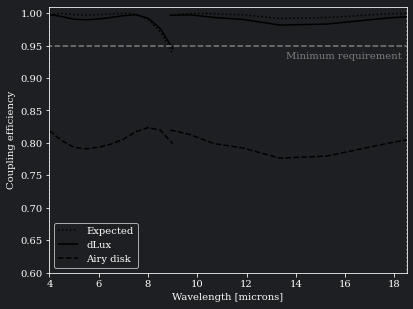

In [6]:
plt.figure()
plt.plot(np.array(wav_TAS)*1e6, Ceff_TAS_apod[:,0], color="k", ls="dotted")
plt.plot(np.array(wav_TAS)*1e6, Ceff_TAS_apod[:,1], color="k", ls="dashed")
plt.plot(np.array(wav_TAS)*1e6, Ceff_TAS_apod[:,2], color="k")
#plt.plot(np.array(wav_TAS)*1e6, Ceff_TAS_noapod[:,2], color="tab:orange", ls="-.")
plt.plot(np.array(wav_AgBr)*1e6, Ceff_AgBr_apod[:,0], color="k", ls="dotted")
plt.plot(np.array(wav_AgBr)*1e6, Ceff_AgBr_apod[:,1], color="k", ls="dashed")
plt.plot(np.array(wav_AgBr)*1e6, Ceff_AgBr_apod[:,2], color="k")
#plt.plot(np.array(wav_AgBr)*1e6, Ceff_AgBr_noapod[:,2], color="tab:blue", ls="-.")
plt.hlines(-1, 0, 1, ls="dotted", color="k", label="Expected")
plt.hlines(-1, 0, 1, color="k", label="dLux")
plt.hlines(-1, 0, 1, ls="dashed", color="k", label="Airy disk")
plt.vlines(4, 0, 2, ls='dotted', color="tab:gray")
plt.vlines(18.5, 0, 2, ls='dotted', color="tab:gray")
plt.hlines(0.95, 0, 30, ls="dashed", color="tab:gray")
plt.text(13.6, 0.93, "Minimum requirement", color="tab:gray")
plt.xlim(min(wav_TAS)*1e6, 18.5)
plt.ylim(0.6, 1.01)
plt.ylabel("Coupling efficiency")
plt.xlabel("Wavelength [microns]")
plt.legend()
plt.savefig("images/Ceff_ideal.png", dpi = 300, bbox_inches = "tight")
plt.show()

# Tolerancing of M1 and M2

## Tolerance on slope error

## Tolerance on spot errors

## Tolerance on positioning